In [1]:
import os
import json
import glob
import matplotlib.pyplot as plt


In [ ]:
def plot_metric(base_dir, key, values, loss_key="l2_loss"):
    ""
    config_paths = [os.path.join(base_dir, f"{i}/config.json") for i in os.listdir(base_dir)]

    json_paths = [os.path.join(base_dir, f"{i}/eval_results.json") for i in os.listdir(base_dir)]
    # convert to set only if filtering is requested
    allowed_set = set(values) if values is not None else None

    x_vals = []
    y_vals = []

    for path in json_paths:
        try:
            with open(path, "r") as f:
                data = json.load(f)
            # skip if keys don't exist
            if key not in data or loss_key not in data:
                continue

            x = data[key]
            y = data[loss_key]
            # normalize floats like 100.0 → 100 for comparison
            if isinstance(x, float):
                x = int(x)
            # apply filter ONLY if values is provided
            if allowed_set is None or x in allowed_set:
                x_vals.append(x)
                y_vals.append(y)

        except Exception as e:
            print(f"skipping {path}: {e}")

    if not x_vals:
        print("no matching files found.")
        return

    # sort by x-axis for clean line plot
    sorted_pairs = sorted(zip(x_vals, y_vals), key=lambda p: p[0])
    x_vals, y_vals = zip(*sorted_pairs)

    plt.figure(figsize=(6, 4))
    plt.plot(x_vals, y_vals, marker="o")
    plt.xlabel(key)
    plt.ylabel(loss_key)
    plt.title(f"{key} vs {loss_key}")
    plt.grid(True)
    plt.show()


['./run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_8/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_2/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_4/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_3/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_0/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_1/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_9/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_7/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5/trainer_5/eval_results.json', './run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5

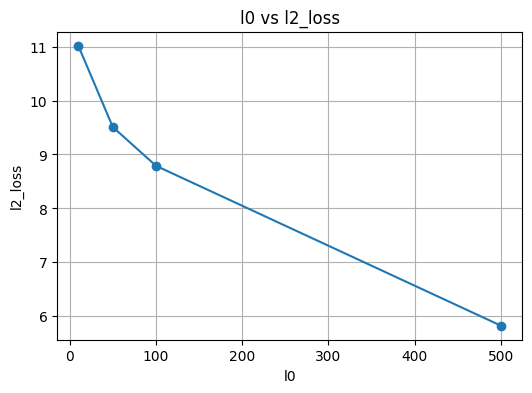

In [5]:
dir = "./run_EleutherAI_pythia-160m_standard_top_k/instruct/resid_post_layer_5"
key = "l0"
values = [10, 50, 100, 500]

plot_metric(dir, key, values)